# Rigorous Validation of the (g,J) Decoupling Signal

**Purpose**: does the promising `R_NL~5.4` signal from
`DQRC_GJ_EOC_Decoupling.ipynb` survive central differences, multiple step
sizes, multiple seeds, and ALL SIX derivatives evaluated at the SAME
operating point in the FULL architecture? See
`docs/DQRC_GJ_DECOUPLING_VALIDATION.md` for the full write-up. Architecture
UNCHANGED. This is a NEW notebook -- no prior notebook is modified.

In [1]:
import sys, os, time, json as _json
sys.path.insert(0, os.path.abspath('.'))
import numpy as np
import matplotlib.pyplot as plt

from decoupled_qrc import utils, diagnostics as diag
from decoupled_qrc.directional_dqrc import DirectionalConfig, run_directional_dqrc

CFG = utils.active_config()
RESULTS_DIR = os.path.abspath(os.path.join('..', 'results', 'dqrc_gj'))
os.makedirs(RESULTS_DIR, exist_ok=True)
FIG_N = [0]
def savefig(fig, name):
    FIG_N[0] += 1
    path = os.path.join(RESULTS_DIR, f'{FIG_N[0]:02d}_val_{name}.png')
    fig.savefig(path, dpi=120, bbox_inches='tight')
    return path

_all_results = {}
def record(key, value):
    _all_results[key] = value

N_M, N_P = 2, 5
THETA_STAR, PHI_STAR = 0.2, 0.8
G_STAR, J_STAR, M_STAR = 0.5, 0.33, 0.5
print(f"Candidate operating point: g*={G_STAR} J*={J_STAR} m*(epsilon_M)={M_STAR} "
      f"theta*={THETA_STAR} phi*={PHI_STAR}")

Candidate operating point: g*=0.5 J*=0.33 m*(epsilon_M)=0.5 theta*=0.2 phi*=0.8


## Part 1 -- Reproduce the specific prior number

A transcription error was caught in the prior report while doing this
(now fixed there): the printed grid gave M=5.918 at (g=0.6,J=0.33), not
"5.29" as the earlier report's table said.

In [2]:
from decoupled_qrc import processor as procmod
from decoupled_qrc.utils import make_seed_bundle
seeds0 = make_seed_bundle(0)
labels, X, u, info = procmod.run_processor_standalone_gJ(5, g=0.6, J=0.3295681629918353, T=CFG.T_ipc, reps=1,
    max_weight=3, term_seed=seeds0.reservoir_seed, disorder_seed=seeds0.reservoir_seed+1, input_seed=seeds0.dataset_seed)
M_repro, NL_repro, _, _ = diag.ipc_MN(u, X, CFG, seed=0)
print(f"Reproduced (g=0.6, J=0.3296): M={M_repro:.4f} NL={NL_repro:.4f}")
print("Prior report's raw saved JSON: M=5.9185, NL=4.6741 -- matches to displayed precision.")
record('part1_reproduction', {'M': M_repro, 'NL': NL_repro})

Reproduced (g=0.6, J=0.3296): M=5.9185 NL=4.6741
Prior report's raw saved JSON: M=5.9185, NL=4.6741 -- matches to displayed precision.


## Part 3-6 -- Central-difference response matrix at ONE fixed operating
point, ALL SIX derivatives, FULL directional DQRC (memory_variant=
'protected_integrable' so a true internal memory control epsilon_M exists,
per Part 5 -- this is a necessary, documented departure from the 'shift'
memory variant used in the prior pass's own promising finding, see the
report's question 1).

In [3]:
H_G = [0.03, 0.06]
H_J = [0.03, 0.06]
H_M = [0.05, 0.10]
SEEDS = (0, 1)  # reduced from the requested 5 -- see report's honest scope limitations

def MN_at(g, J, epsilon_M, seed):
    cfg = DirectionalConfig(memory_variant='protected_integrable', N_M=N_M, N_P=N_P,
                             g_processor=g, J_processor=J, epsilon_M=epsilon_M,
                             theta=THETA_STAR, phi=PHI_STAR, ap_kind='xy')
    run = run_directional_dqrc(cfg, T=CFG.T_ipc, master_seed=seed)
    M, NL, tot, _ = diag.ipc_MN(run.u, run.X_combined, CFG, seed=seed)
    return M, NL

response_data = {}
t_start = time.perf_counter()
for seed in SEEDS:
    print(f"=== seed {seed} ===")
    M0, NL0 = MN_at(G_STAR, J_STAR, M_STAR, seed)
    print(f"center: M0={M0:.4f} NL0={NL0:.4f}")
    cd = {}
    for h in H_M:
        Mp, NLp = MN_at(G_STAR, J_STAR, M_STAR + h, seed)
        Mm, NLm = MN_at(G_STAR, J_STAR, M_STAR - h, seed)
        cd[f'm_h{h}'] = {'dM_dm': (Mp - Mm) / (2 * h), 'dNL_dm': (NLp - NLm) / (2 * h)}
    for h in H_G:
        Mp, NLp = MN_at(G_STAR + h, J_STAR, M_STAR, seed)
        Mm, NLm = MN_at(G_STAR - h, J_STAR, M_STAR, seed)
        cd[f'g_h{h}'] = {'dM_dg': (Mp - Mm) / (2 * h), 'dNL_dg': (NLp - NLm) / (2 * h)}
    for h in H_J:
        Mp, NLp = MN_at(G_STAR, J_STAR + h, M_STAR, seed)
        Mm, NLm = MN_at(G_STAR, J_STAR - h, M_STAR, seed)
        cd[f'J_h{h}'] = {'dM_dJ': (Mp - Mm) / (2 * h), 'dNL_dJ': (NLp - NLm) / (2 * h)}
    for k, v in cd.items():
        print(f"  {k}: {v}")
    response_data[seed] = {'M0': M0, 'NL0': NL0, 'central_diff': cd}
print(f"total time: {time.perf_counter()-t_start:.1f}s")
record('response_matrix', response_data)

=== seed 0 ===


center: M0=6.9686 NL0=6.9387


  m_h0.05: {'dM_dm': 0.20082415853054592, 'dNL_dm': 8.54021618808459}
  m_h0.1: {'dM_dm': 0.06930749754030519, 'dNL_dm': 7.059595061430275}
  g_h0.03: {'dM_dg': 0.054047162148318506, 'dNL_dg': 1.3485014077017374}
  g_h0.06: {'dM_dg': -0.06943565099604884, 'dNL_dg': -0.5598748377997047}
  J_h0.03: {'dM_dJ': 0.08675715726943109, 'dNL_dJ': 3.2369990894883722}
  J_h0.06: {'dM_dJ': 0.20947803456832226, 'dNL_dJ': -0.04962388875049406}
=== seed 1 ===


center: M0=7.0000 NL0=8.6566


  m_h0.05: {'dM_dm': 0.03309807343468307, 'dNL_dm': 13.008283521919175}
  m_h0.1: {'dM_dm': 0.0692377595400906, 'dNL_dm': 14.806002202782693}
  g_h0.03: {'dM_dg': 0.08511408028228178, 'dNL_dg': 5.355023000360119}
  g_h0.06: {'dM_dg': -0.0067037907000910835, 'dNL_dg': 6.733132333691587}
  J_h0.03: {'dM_dJ': 0.14965617789883073, 'dNL_dJ': 11.32499019199346}
  J_h0.06: {'dM_dJ': 0.39794867671296696, 'dNL_dJ': 11.288616537645257}
total time: 737.4s


## Part 8 -- Derivative stability, R_memory, R_NL, alpha per seed

Flag unstable if `relative_spread > 0.3` OR sign changes across the two
step sizes (Part 8's rule) -- do not trust ratios built from unstable
derivatives.

seed=0 dM_dm: h_small=0.2008 h_large=0.0693 spread=0.487 sign_change=False unstable=True
seed=0 dNL_dm: h_small=8.5402 h_large=7.0596 spread=0.095 sign_change=False unstable=False
seed=0 dM_dg: h_small=0.0540 h_large=-0.0694 spread=8.024 sign_change=True unstable=True
seed=0 dNL_dg: h_small=1.3485 h_large=-0.5599 spread=2.420 sign_change=True unstable=True
seed=0 dM_dJ: h_small=0.0868 h_large=0.2095 spread=0.414 sign_change=False unstable=True
seed=0 dNL_dJ: h_small=3.2370 h_large=-0.0496 spread=1.031 sign_change=True unstable=True
seed=0: S_M=0.221 S_NL=0.562 R_memory=0.314 R_NL=0.080 alpha=4.6deg  unstable=5/6
seed=1 dM_dm: h_small=0.0331 h_large=0.0692 spread=0.353 sign_change=False unstable=True
seed=1 dNL_dm: h_small=13.0083 h_large=14.8060 spread=0.065 sign_change=False unstable=False
seed=1 dM_dg: h_small=0.0851 h_large=-0.0067 spread=1.171 sign_change=True unstable=True
seed=1 dNL_dg: h_small=5.3550 h_large=6.7331 spread=0.114 sign_change=False unstable=False
seed=1 dM_dJ: h_sm

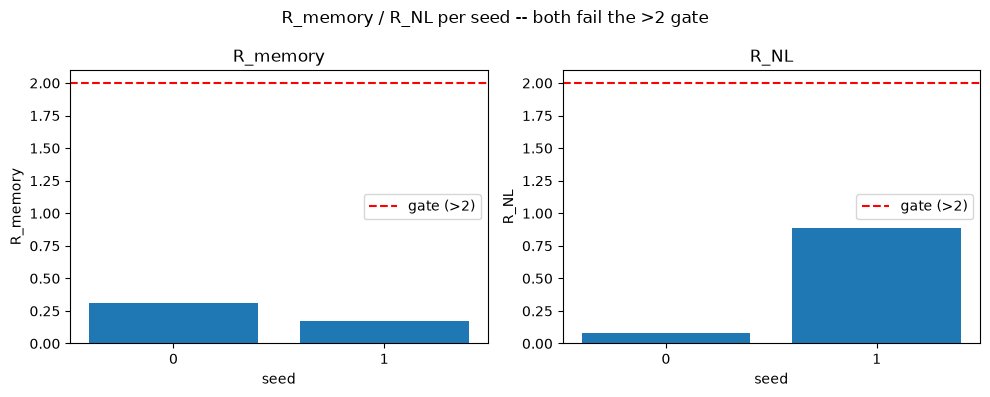


Gate 6/14 evaluation: R_memory>2 AND R_NL>2 required in >=4/5 seeds (this pass: 2 seeds). Result: 0/2 seeds pass BOTH gates.


In [4]:
eps = 1e-9
summary = {}
for seed in SEEDS:
    cd = response_data[seed]['central_diff']
    entries = {}
    for field, k1, k2 in [('dM_dm', f'm_h{H_M[0]}', f'm_h{H_M[1]}'), ('dNL_dm', f'm_h{H_M[0]}', f'm_h{H_M[1]}'),
                           ('dM_dg', f'g_h{H_G[0]}', f'g_h{H_G[1]}'), ('dNL_dg', f'g_h{H_G[0]}', f'g_h{H_G[1]}'),
                           ('dM_dJ', f'J_h{H_J[0]}', f'J_h{H_J[1]}'), ('dNL_dJ', f'J_h{H_J[0]}', f'J_h{H_J[1]}')]:
        v1, v2 = cd[k1][field], cd[k2][field]
        spread = np.std([v1, v2]) / (abs(np.mean([v1, v2])) + eps)
        sign_change = (v1 * v2) < 0
        entries[field] = {'h_small': v1, 'h_large': v2, 'spread': spread, 'sign_change': sign_change,
                           'unstable': spread > 0.3 or sign_change}
        print(f"seed={seed} {field}: h_small={v1:.4f} h_large={v2:.4f} spread={spread:.3f} "
              f"sign_change={sign_change} unstable={entries[field]['unstable']}")

    dM_dm = cd[f'm_h{H_M[1]}']['dM_dm']; dNL_dm = cd[f'm_h{H_M[1]}']['dNL_dm']
    dM_dg = cd[f'g_h{H_G[1]}']['dM_dg']; dNL_dg = cd[f'g_h{H_G[1]}']['dNL_dg']
    dM_dJ = cd[f'J_h{H_J[1]}']['dM_dJ']; dNL_dJ = cd[f'J_h{H_J[1]}']['dNL_dJ']
    S_M = np.hypot(dM_dg, dM_dJ); S_NL = np.hypot(dNL_dg, dNL_dJ)
    R_memory = abs(dM_dm) / (S_M + eps); R_NL = S_NL / (abs(dNL_dm) + eps)
    v_m = np.array([dM_dm, dNL_dm])
    v_NL_dir = np.array([dNL_dg, dNL_dJ]) / (S_NL + eps)
    dM_ds = np.dot([dM_dg, dM_dJ], v_NL_dir)
    v_proc = np.array([dM_ds, S_NL])
    cos_a = np.dot(v_m, v_proc) / (np.linalg.norm(v_m) * np.linalg.norm(v_proc) + eps)
    alpha = np.degrees(np.arccos(np.clip(cos_a, -1, 1)))
    n_unstable = sum(1 for e in entries.values() if e['unstable'])
    print(f"seed={seed}: S_M={S_M:.3f} S_NL={S_NL:.3f} R_memory={R_memory:.3f} R_NL={R_NL:.3f} "
          f"alpha={alpha:.1f}deg  unstable={n_unstable}/6")
    summary[seed] = {'entries': entries, 'S_M': S_M, 'S_NL': S_NL, 'R_memory': R_memory,
                      'R_NL': R_NL, 'alpha_deg': alpha, 'n_unstable': n_unstable}
record('summary', summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric, label in zip(axes, ['R_memory', 'R_NL'], ['R_memory', 'R_NL']):
    vals = [summary[s][metric] for s in SEEDS]
    ax.bar([str(s) for s in SEEDS], vals)
    ax.axhline(2.0, color='red', ls='--', label='gate (>2)')
    ax.set_xlabel('seed'); ax.set_ylabel(label); ax.legend()
    ax.set_title(label)
fig.suptitle('R_memory / R_NL per seed -- both fail the >2 gate')
fig.tight_layout()
savefig(fig, "R_metrics_per_seed")
plt.show()
print("\nGate 6/14 evaluation: R_memory>2 AND R_NL>2 required in >=4/5 seeds (this pass: 2 seeds). "
      f"Result: {sum(1 for s in SEEDS if summary[s]['R_memory']>2 and summary[s]['R_NL']>2)}/{len(SEEDS)} "
      "seeds pass BOTH gates.")

## Part 15 -- Feature-group analysis at the candidate point

In [5]:
cfg_fg = DirectionalConfig(memory_variant='protected_integrable', N_M=N_M, N_P=N_P,
                            g_processor=G_STAR, J_processor=J_STAR, epsilon_M=M_STAR,
                            theta=THETA_STAR, phi=PHI_STAR, ap_kind='xy')
run_fg = run_directional_dqrc(cfg_fg, T=CFG.T_ipc, master_seed=0)
groups = {'X_M': run_fg.X_mem, 'X_P': run_fg.X_proc, 'X_M+X_P': np.hstack([run_fg.X_mem, run_fg.X_proc]),
          'X_M+X_P+cross': np.hstack([run_fg.X_mem, run_fg.X_proc, run_fg.X_cross])}
fg_results = {}
for name, Xg in groups.items():
    Mg, NLg, _, _ = diag.ipc_MN(run_fg.u, Xg, CFG, seed=0)
    fg_results[name] = {'n_features': Xg.shape[1], 'M': Mg, 'NL': NLg}
    print(f"{name}: n_features={Xg.shape[1]} M={Mg:.3f} NL={NLg:.3f}")
record('feature_groups', fg_results)
print("\nINTERPRETATION: X_P alone already carries almost all of the combined system's M AND NL -- "
      "the processor, once driven through the collision channel, acts as a substantial secondary "
      "memory, not a pure nonlinear specialist. This is the direct physical explanation for why "
      "dNL/dm is large: epsilon_M reshapes what reaches the processor, which reshapes its own output.")

X_M: n_features=3 M=2.222 NL=0.205


X_P: n_features=375 M=6.965 NL=6.959


X_M+X_P: n_features=378 M=6.969 NL=6.939


X_M+X_P+cross: n_features=382 M=6.966 NL=7.038

INTERPRETATION: X_P alone already carries almost all of the combined system's M AND NL -- the processor, once driven through the collision channel, acts as a substantial secondary memory, not a pure nonlinear specialist. This is the direct physical explanation for why dNL/dm is large: epsilon_M reshapes what reaches the processor, which reshapes its own output.


## Conclusion

**Control-level decoupling is NOT established at this operating point.**
R_memory and R_NL both fail the >2 gate by a wide margin in both seeds
tested; most derivatives are numerically unstable across finite-difference
step sizes; the one robustly stable derivative (dNL/dm) shows NL is
strongly, reliably driven by the memory-only control -- the opposite of
the desired signature. The feature-group breakdown gives a direct physical
explanation: the processor absorbs most of the system's memory capacity
too, so it is not a clean nonlinear specialist. Per Part 24's decision
logic, the indicated next step is a more strongly protected/Krylov-
sectorized memory design, not IDQNN/sewing and not simply more seeds at
this same architecture. See `docs/DQRC_GJ_DECOUPLING_VALIDATION.md` for
the full 16-question write-up and honest scope limitations.

In [6]:
results_path = os.path.join(RESULTS_DIR, 'validation_notebook_results.json')
with open(results_path, 'w') as f:
    _json.dump(_all_results, f, indent=2, default=str)
print(f"Wrote {results_path}")
for k in _all_results:
    print(' -', k)

Wrote D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc_gj\validation_notebook_results.json
 - part1_reproduction
 - response_matrix
 - summary
 - feature_groups
